## Objetivo

O objetivo deste trabalho é aplicar o Método da Secante para encontrar raízes de funções, analisar como ele se comporta ao longo das iterações e comparar com os métodos da Bissecção e de Newton.

## Função analisada

A função escolhida para essa análise foi:

f(x) = cos(x) - x

Escolhemos essa função porque ela é contínua, fácil de trabalhar e possui uma raiz real que dá pra visualizar bem no gráfico. Isso facilita na hora de comparar os métodos.

## Introdução

O Método da Secante é um método numérico usado para encontrar raízes de equações do tipo \(f(x)=0\). Ele funciona de forma iterativa, usando dois valores iniciais e aproximando a raiz através de uma reta secante entre esses pontos.

Diferente do método de Newton, ele não precisa da derivada da função, o que pode ser uma vantagem em alguns casos. Porém, sua convergência depende bastante dos valores iniciais escolhidos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def f(x):
    return np.cos(x) - x

In [3]:
def df(x):
    return -np.sin(x) - 1

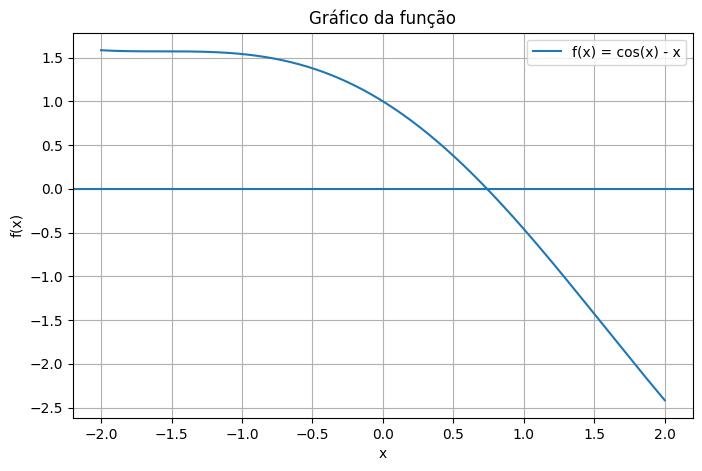

In [4]:
x = np.linspace(-2, 2, 400)
y = f(x)

plt.figure(figsize=(8,5))
plt.plot(x, y, label='f(x) = cos(x) - x')

plt.axhline(0)  # linha do eixo x

plt.grid()
plt.legend()

plt.title('Gráfico da função')
plt.xlabel('x')
plt.ylabel('f(x)')

plt.show()

## Análise gráfica

Pelo gráfico da função, é possível observar que ela cruza o eixo x aproximadamente na região de x ≈ 0,7. Isso indica que existe uma raiz real nesse intervalo.

Além disso, como a função é contínua, podemos afirmar que os métodos numéricos utilizados (Bissecção, Newton e Secante) devem conseguir encontrar essa raiz, desde que sejam escolhidos bons valores iniciais.

## Método da Secante

In [5]:
def secante(f, x0, x1, tol=1e-6, max_iter=100):
    dados = []

    for i in range(max_iter):
        fx0 = f(x0)
        fx1 = f(x1)

        # evitar divisão por zero
        if fx1 - fx0 == 0:
            print("Erro: divisão por zero")
            return pd.DataFrame(dados), None

        x2 = x1 - fx1 * (x1 - x0) / (fx1 - fx0)
        erro = abs(x2 - x1)

        dados.append([i, x1, fx1, erro])

        if erro < tol:
            return pd.DataFrame(dados, columns=["Iteração", "x_n", "f(x_n)", "erro"]), x2

        x0, x1 = x1, x2

    return pd.DataFrame(dados, columns=["Iteração", "x_n", "f(x_n)", "erro"]), x2

In [6]:
tabela_secante, raiz_secante = secante(f, 0, 1)

print("Raiz aproximada:", raiz_secante)
tabela_secante

Raiz aproximada: 0.7390851332150012


,Iteração,x_n,f(x_n),erro
0,0,1.000000,-4.596977e-01,3.149266e-01
1,1,0.685073,8.929928e-02,5.122564e-02
2,2,0.736299,4.660039e-03,2.820364e-03
3,3,0.739119,-5.728599e-05,3.424978e-05
4,4,0.739085,3.529262e-08,2.108754e-08


## Resultado do Método da Secante

O método da secante convergiu para a raiz da função com poucas iterações.

A raiz encontrada foi aproximadamente x ≈ 0,739, o que está de acordo com a análise gráfica feita anteriormente.

Observa-se que o erro diminui rapidamente a cada iteração, indicando uma boa velocidade de convergência.

## Método da Bissecção

In [7]:
def bisseccao(f, a, b, tol=1e-6, max_iter=100):
    if f(a) * f(b) > 0:
        print("Não há troca de sinal no intervalo.")
        return pd.DataFrame(), None

    dados = []

    for i in range(max_iter):
        c = (a + b) / 2
        fc = f(c)
        erro = abs(b - a) / 2

        dados.append([i, a, b, c, fc, erro])

        if abs(fc) < tol or erro < tol:
            return pd.DataFrame(dados, columns=["Iteração", "a", "b", "c", "f(c)", "erro"]), c

        if f(a) * fc < 0:
            b = c
        else:
            a = c

    return pd.DataFrame(dados, columns=["Iteração", "a", "b", "c", "f(c)", "erro"]), c

In [8]:
tabela_biss, raiz_biss = bisseccao(f, 0, 1)

print("Raiz aproximada pela Bissecção:", raiz_biss)
tabela_biss

Raiz aproximada pela Bissecção: 0.7390851974487305


,Iteração,a,b,c,f(c),erro
0,0,0.000000,1.000000,0.500000,3.775826e-01,5.000000e-01
1,1,0.500000,1.000000,0.750000,-1.831113e-02,2.500000e-01
2,2,0.500000,0.750000,0.625000,1.859631e-01,1.250000e-01
3,3,0.625000,0.750000,0.687500,8.533495e-02,6.250000e-02
4,4,0.687500,0.750000,0.718750,3.387937e-02,3.125000e-02
5,5,0.718750,0.750000,0.734375,7.874725e-03,1.562500e-02
6,6,0.734375,0.750000,0.742188,-5.195712e-03,7.812500e-03
7,7,0.734375,0.742188,0.738281,1.345150e-03,3.906250e-03
8,8,0.738281,0.742188,0.740234,-1.923873e-03,1.953125e-03
9,9,0.738281,0.740234,0.739258,-2.890091e-04,9.765625e-04


## Resultado da Bissecção

O método da Bissecção também convergiu para a raiz da função no intervalo analisado.

Ele apresentou convergência garantida, já que a função muda de sinal entre 0 e 1. Porém, comparado com outros métodos, sua convergência é mais lenta, pois o intervalo vai sendo reduzido aos poucos a cada iteração.

## Método de Newton

In [9]:
def newton(f, df, x0, tol=1e-6, max_iter=100):
    dados = []

    for i in range(max_iter):
        fx = f(x0)
        dfx = df(x0)

        if dfx == 0:
            print("Derivada zero. O método falhou.")
            return pd.DataFrame(dados), None

        x1 = x0 - fx / dfx
        erro = abs(x1 - x0)

        dados.append([i, x0, fx, erro])

        if erro < tol:
            return pd.DataFrame(dados, columns=["Iteração", "x_n", "f(x_n)", "erro"]), x1

        x0 = x1

    return pd.DataFrame(dados, columns=["Iteração", "x_n", "f(x_n)", "erro"]), x1

In [10]:
tabela_newton, raiz_newton = newton(f, df, 1)

print("Raiz aproximada por Newton:", raiz_newton)
tabela_newton

Raiz aproximada por Newton: 0.7390851332151607


,Iteração,x_n,f(x_n),erro
0,0,1.000000,-4.596977e-01,2.496361e-01
1,1,0.750364,-1.892307e-02,1.125098e-02
2,2,0.739113,-4.645590e-05,2.775753e-05
3,3,0.739085,-2.847206e-10,1.701234e-10


## Resultado de Newton

O método de Newton convergiu rapidamente para a raiz da função.

Entre os métodos testados até aqui, ele tende a apresentar menos iterações, desde que o valor inicial seja adequado. Sua principal vantagem é a rapidez, mas ele exige o uso da derivada da função.

## Comparação entre os métodos

In [11]:
comparacao = pd.DataFrame({
    "Método": ["Bissecção", "Newton", "Secante"],
    "Iterações até convergir": [
        len(tabela_biss),
        len(tabela_newton),
        len(tabela_secante)
    ]
})

comparacao

,Método,Iterações até convergir
0,Bissecção,20
1,Newton,4
2,Secante,5


Pela comparação do número de iterações, é possível perceber a diferença no comportamento dos métodos.

A Bissecção apresentou mais iterações, mas tem a vantagem de ser mais segura. O método de Newton convergiu mais rapidamente, enquanto a Secante também apresentou boa velocidade de convergência, com a vantagem de não precisar da derivada.

### 1. Qual método convergiu mais rapidamente?

Entre os métodos testados, o método de Newton foi o que convergiu mais rapidamente, precisando de menos iterações para chegar na raiz.

O método da Secante também teve uma convergência rápida e ficou bem próximo do desempenho de Newton. Já a Bissecção demorou mais, porque reduz o intervalo aos poucos e de forma mais conservadora.

### 2. A Secante sempre converge?

Não. O método da Secante não converge em todos os casos.

A convergência depende bastante da escolha dos valores iniciais e do comportamento da função. Em algumas situações ele encontra a raiz rapidamente, mas em outras pode demorar, oscilar ou até falhar.

In [12]:
testes = [(0, 1), (1, 2), (-1, 1), (5, 6)]

for x0, x1 in testes:
    tabela_teste, raiz_teste = secante(f, x0, x1)
    print(f"Valores iniciais: {x0} e {x1}")
    print(f"Raiz encontrada: {raiz_teste}")
    print(f"Número de iterações: {len(tabela_teste)}")
    print("-" * 40)

Valores iniciais: 0 e 1
Raiz encontrada: 0.7390851332150012
Número de iterações: 5
----------------------------------------
Valores iniciais: 1 e 2
Raiz encontrada: 0.7390851332152121
Número de iterações: 5
----------------------------------------
Valores iniciais: -1 e 1
Raiz encontrada: 0.7390851332151607
Número de iterações: 6
----------------------------------------
Valores iniciais: 5 e 6
Raiz encontrada: 0.7390851332149018
Número de iterações: 8
----------------------------------------


Testando diferentes valores iniciais, dá para perceber que o método da Secante pode ter comportamentos diferentes. Em alguns casos ele converge bem, mas em outros a convergência pode ser pior ou até não acontecer da forma esperada.

### 3. Em quais situações o método da Secante pode falhar?

O método da Secante pode falhar quando os valores iniciais não são bons ou quando os valores da função ficam muito próximos, causando problemas no cálculo.

Algumas situações em que ele pode dar errado são:

- quando os pontos iniciais estão muito longe da raiz;
- quando a função tem comportamento complicado na região;
- quando ocorre divisão por um valor muito pequeno;
- quando o método começa a oscilar em vez de se aproximar da raiz.

### 4. Compare a necessidade de informação adicional entre os métodos

Os três métodos têm exigências diferentes.

**Bissecção:** precisa de um intervalo em que a função mude de sinal. É simples e seguro, mas pode ser mais lento.

**Newton:** precisa de um valor inicial e também da derivada da função. Costuma ser muito rápido, mas depende de mais informação.

**Secante:** precisa de dois valores iniciais, mas não precisa da derivada. Por isso, acaba sendo um meio-termo interessante entre simplicidade e velocidade.

### 5. Se você estivesse desenvolvendo um software de engenharia, qual método escolheria e por quê?

Se eu estivesse desenvolvendo um software de engenharia para encontrar raízes de funções desconhecidas, eu provavelmente escolheria uma abordagem combinada.

A Bissecção seria uma boa opção para começar, porque é mais estável e segura quando existe troca de sinal no intervalo. Depois, quando a aproximação já estivesse perto da raiz, Newton ou Secante poderiam ser usados para acelerar a convergência.

Se fosse para escolher apenas um método, a Secante seria uma boa escolha, porque tem boa velocidade e não exige a derivada da função.